# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
   
   A model is linear when it models the relationship between variables with a linear fit line.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   
   The coefficient is interpreted relative to the baseline label that was dropped. The intercept corresponds to the dropped label.
   
3. Can linear regression be used for classification? Explain why, or why not.
   
   Yes, if the features are binary, in which case the model would output a probability distribution.
   
4. What are signs that your linear model is over-fitting?
   
   When the coefficients are unstable, and small changes in data lead to large changes in coefficients.
   
5. Clearly explain multi-colinearity using the two-stage least squares technique.
   
   Two-stage least squares can reduce multicollinearity by isolating the variation in specific variables to avoid overlap with other variables.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
   
   We can apply nonlinear transformations to linear coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?
   
   How the predicted outcome changes when a feature changes.
   
8. Compare the train/test split and $k$-fold cross validation.
   
   Train/test split trains the data once on one split and tests on the other. $k$-fold splits the data into equal folds and trains on $k$-1 folds and tests on the other, repeating $k$ times.

9. How is the $k$ in $k$-fold cross validation typically selected?
    
   Chosen to minimize loss function.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
   
   Manhattan
   
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
   
   The estimated coefficient for the Bronx is the same as its conditional group mean. The model underestimated the group mean for all the other neighborhoods.
   
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
   
   The price increases by $1.02 for every 1-point increase in `Review Scores Rating`.
   
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
   
   The slope coefficient for `Review Score Rating` increased slightly to 1.08 while the neighborhood averages stayed about the same, with the exception of the Bronx, which has dropped significantly from 75.28 to -23.81.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
   
   The slopes are similar for Brooklyn and Manhattan but not the other neighborhoods.
   
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_airbnb = pd.read_csv("data/Q1_clean.csv")

df_airbnb.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [11]:
avg_df = df_airbnb.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()
avg_df

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


<Axes: xlabel='Price', ylabel='Density'>

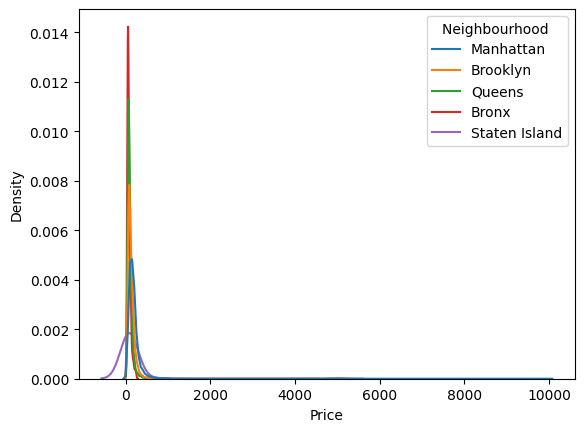

In [18]:
sns.kdeplot(df_airbnb, x="Price", hue="Neighbourhood ", common_norm=False)

<Axes: xlabel='Log_Price', ylabel='Density'>

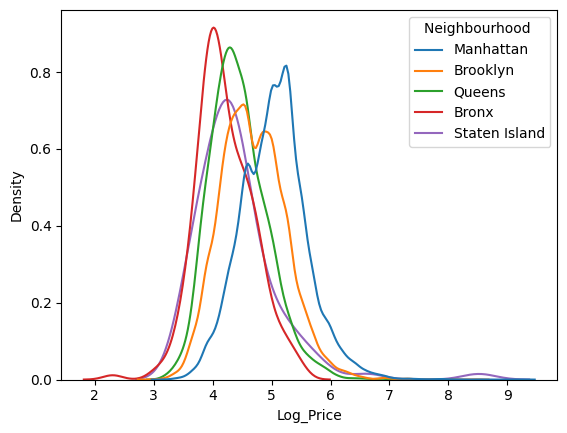

In [20]:
df_airbnb["Log_Price"] = np.log(df_airbnb["Price"])

sns.kdeplot(df_airbnb, x="Log_Price", hue="Neighbourhood ", common_norm=False)

In [73]:
from sklearn.linear_model import LinearRegression

tdf = df_airbnb.loc[:, ["Price", "Review Scores Rating", "Neighbourhood "]]
y1 = tdf["Price"]
neighborhood_ohe = pd.get_dummies(tdf["Neighbourhood "], dtype="int", drop_first=True)
X1=neighborhood_ohe

model1 = LinearRegression()
model1 = model1.fit(X1, y1)

print(f'Model intercept (Bronx): {model1.intercept_}')
pd.DataFrame({'variable':model1.feature_names_in_, 'coefficient':model1.coef_ })

Model intercept (Bronx): 75.27649769584667


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [48]:
y2 = tdf["Price"]
X2 = tdf[["Review Scores Rating"]]

model2 = LinearRegression()
model2 = model2.fit(X2, y2)

print(f'Model intercept: {model2.intercept_}')
pd.DataFrame({'variable':model2.feature_names_in_, 'coefficient':model2.coef_ })

Model intercept: 60.878390657123816


,variable,coefficient
0,Review Scores Rating,1.020827


In [74]:
y3 = tdf["Price"]
X3_num = tdf[["Review Scores Rating"]]
X3_cat = neighborhood_ohe
X3 = pd.concat([X3_num, X3_cat], axis=1)

model3 = LinearRegression()
model3 = model3.fit(X3, y3)

print(f'Model intercept: {model3.intercept_}')
pd.DataFrame({'variable':model3.feature_names_in_, 'coefficient':model3.coef_ })

Model intercept: -23.81256101167321


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


In [139]:
y4 = tdf["Price"]
interaction_terms = neighborhood_ohe.multiply(tdf["Review Scores Rating"], axis=0)
interaction_terms = interaction_terms.rename(columns=lambda x: f"Rating_x_{x}")
X4 = pd.concat([neighborhood_ohe, tdf["Review Scores Rating"], interaction_terms], axis=1)

model4 = LinearRegression()
model4 = model4.fit(X4, y4)

print(f'Model intercept: {model4.intercept_}')
pd.DataFrame({'variable':model4.feature_names_in_, 'coefficient':model4.coef_ })

Model intercept: 22.63838492121573


,variable,coefficient
0,Brooklyn,-16.392990
1,Manhattan,41.315429
2,Queens,28.259701
3,Staten Island,2963.071040
4,Review Scores Rating,0.574311
5,Rating_x_Brooklyn,0.741165
6,Rating_x_Manhattan,0.729703
7,Rating_x_Queens,-0.072294
8,Rating_x_Staten Island,-31.831748


In [76]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score(
    model3, X3, y3,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

print("Model 3")
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model 3
Fold scores: [-13328.8844614  -17923.91602978 -22359.73425128 -20638.78463036
 -16213.77913811 -15968.25148456 -65543.4120206  -11112.83183507
 -12726.79546542 -14924.58455652]
Mean score: -21074.09738730938
Median score: -16091.015311334519
Std dev: 15184.490093017015


In [77]:
scores = cross_val_score(
    model4, X4, y4,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

print("Model 4")
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model 4
Fold scores: [-13651.39402828 -18041.63445512 -22439.57433037 -21154.75504879
 -17344.73843257 -16072.72994399 -65397.17732163 -11351.99120315
 -12853.37506753 -15040.17830152]
Mean score: -21334.754813295112
Median score: -16708.73418827814
Std dev: 15058.050935045349


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
   
     SUVs are the most expensive on average and have the most variance.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
   
     Price increases by 59268 rupees for every 1 increase in seating capacity.
     Differences in price are not linear to the number of seats.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?\
   
     The model underestimates the real price but it roughly fits the trends in the actual data.


In [55]:
df_cars = pd.read_csv("data/cars_hw.csv")
df_cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [59]:
df_cars["Price"].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

<Axes: xlabel='Price', ylabel='Density'>

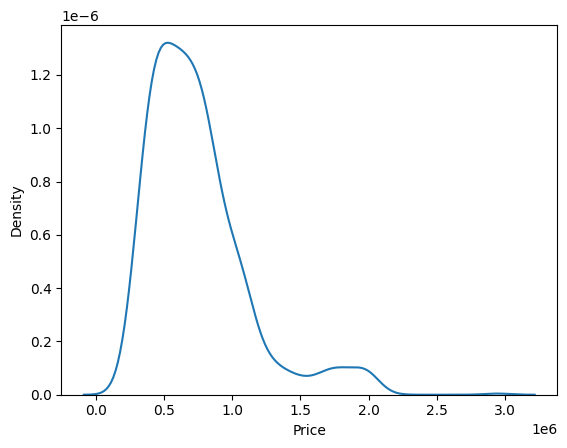

In [60]:
sns.kdeplot(df_cars["Price"])

In [61]:
df_cars.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


<Axes: xlabel='Price', ylabel='Density'>

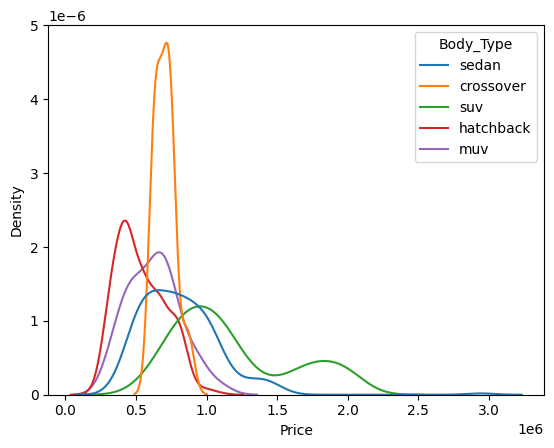

In [62]:
sns.kdeplot(df_cars, x="Price", hue="Body_Type", common_norm=False)

In [68]:
y = df_cars["Price"]
X = df_cars[["Seating_Capacity"]]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 439032.0141018268


,variable,coefficient
0,Seating_Capacity,59267.998037


In [69]:
y = df_cars["Price"]
X = pd.get_dummies(df_cars["Seating_Capacity"], prefix="Seating_Capacity", dtype="int", drop_first=True)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 188000.00000000163


,variable,coefficient
0,Seating_Capacity_5,5.464839e+05
1,Seating_Capacity_6,1.456000e+06
2,Seating_Capacity_7,7.359487e+05
3,Seating_Capacity_8,2.718000e+05


In [ ]:
df_cars["Age"] = 2026 - df_cars["Make_Year"]
df_cars["Age"].head()

0     9
1    10
2     7
3     9
4     9
Name: Age, dtype: int64

In [91]:
from sklearn.preprocessing import PolynomialFeatures

y = df_cars["Price"]
X = df_cars[["Age"]]
cv_errors = {}

for degree in range(1, 21):
    expander = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = expander.fit_transform(X)

    model = LinearRegression()

    mse = cross_val_score(model, X_poly, y, cv=kfold, scoring="neg_mean_squared_error") * -1
    cv_errors[degree] = np.mean(mse)
    print(f"Degree {degree}: Mean Squared Error = {np.mean(mse)}")

print(f"\nBest Degree: {(min_key := min(cv_errors, key=cv_errors.get))} with Mean Squared Error = {cv_errors[min_key]}")

Degree 1: Mean Squared Error = 97593991873.84819
Degree 2: Mean Squared Error = 97788769710.30014
Degree 3: Mean Squared Error = 97182824586.8536
Degree 4: Mean Squared Error = 96657152963.8893
Degree 5: Mean Squared Error = 95734209145.66212
Degree 6: Mean Squared Error = 95928603342.56955
Degree 7: Mean Squared Error = 95394591202.01765
Degree 8: Mean Squared Error = 95673784927.03928
Degree 9: Mean Squared Error = 95632521174.51868
Degree 10: Mean Squared Error = 95354961021.25189
Degree 11: Mean Squared Error = 95146664509.8877
Degree 12: Mean Squared Error = 95292198421.84204
Degree 13: Mean Squared Error = 95798290270.94693
Degree 14: Mean Squared Error = 96410294734.43436
Degree 15: Mean Squared Error = 96857270620.18375
Degree 16: Mean Squared Error = 96774022346.16588
Degree 17: Mean Squared Error = 96839358591.06923
Degree 18: Mean Squared Error = 97018749812.8681
Degree 19: Mean Squared Error = 97278264274.67924
Degree 20: Mean Squared Error = 97583764312.97128

Best Degree:

Text(0.5, 1.0, 'Actual Price vs Age')

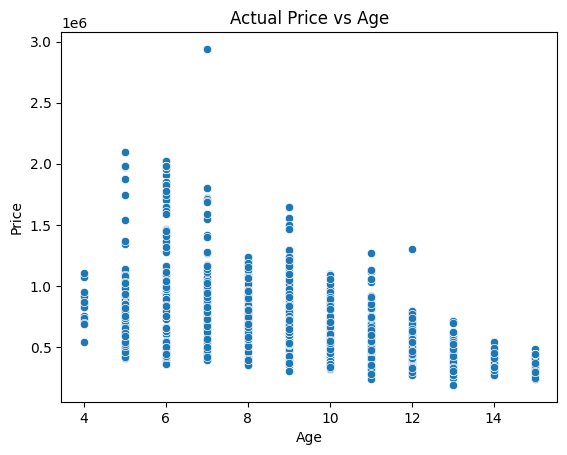

In [102]:
sns.scatterplot(df_cars, x="Age", y="Price")
plt.title("Actual Price vs Age")

Text(0.5, 1.0, 'Predicted Price vs Age')

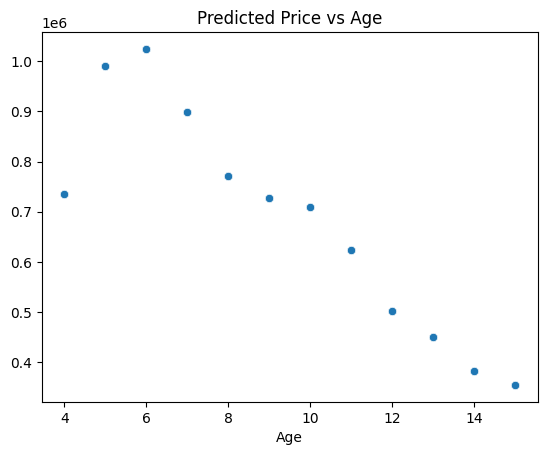

In [129]:
expander = PolynomialFeatures(degree=11, include_bias=False)
X_poly = expander.fit_transform(X)

model = LinearRegression()
model = model.fit(X_poly, y)

sns.scatterplot(df_cars, x="Age", y=model.predict(X_poly))
plt.title("Predicted Price vs Age")

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
   
   ATE = 0.23

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
   
   The intercept and coefficient are exactly the same.
   
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
   
   The coefficient on transplant increases slightly when controlled for age. The intercept represents the surival rate at age = 0 and in the control group, though it mainly serves as the baseline. The coefficient on transplant represents the increase in survival rate for the treatment group holding age constant, and the coefficient on age represents the increase in survival rate as age increases, holding transplant group constant.

   The model overestimates the impact of a transplant for late teens to mid-50s, and underestimates after that.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
   
   The coefficient on transplant increases, but that is assuming age is 0. The coefficient on transplant * age represents how survival rate changes for the treatment group as age increases.

   We can see that the model now predicts siginficant differences in survival rates between young patients and old patients in the treatment group, compared to smaller differences between young patients and old patients in the control group.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
   
   The model still has a significantly large MSE and is too unreliable for use in public health. It also does not take into account more patient variables besides age.


In [109]:
df_heart = pd.read_csv("data/heart_hw.csv")
df_heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [124]:
survival_rate = df_heart.groupby("transplant")["y"].mean()
ate = survival_rate["treatment"] - survival_rate["control"]
print(ate)

0.23017902813299232


In [126]:
survival_rate

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64

In [127]:
y1 = df_heart["y"]
transplant_encoded = pd.get_dummies(df_heart["transplant"], dtype=int, drop_first=True)
X1 = transplant_encoded

model1 = LinearRegression()
model1 = model1.fit(X1, y1)

print(f'Model intercept: {model1.intercept_}')
pd.DataFrame({'variable':model1.feature_names_in_, 'coefficient':model1.coef_ })

Model intercept: 0.11764705882352941


,variable,coefficient
0,treatment,0.230179


In [128]:
y2 = df_heart["y"]
X2 = pd.concat([df_heart["age"], transplant_encoded], axis=1)

model2 = LinearRegression()
model2 = model2.fit(X2, y2)

print(f'Model intercept: {model2.intercept_}')
pd.DataFrame({'variable':model2.feature_names_in_, 'coefficient':model2.coef_ })

Model intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,treatment,0.264702


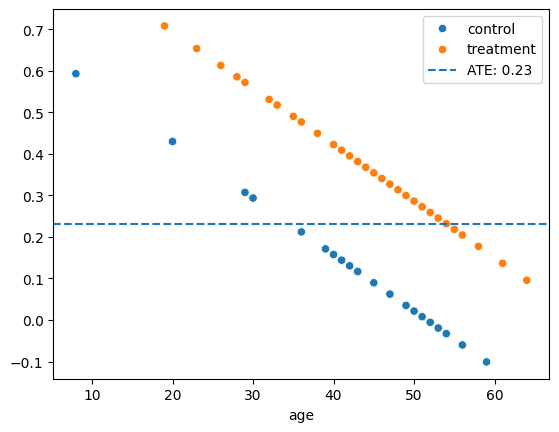

In [136]:
sns.scatterplot(df_heart, x="age", y=model2.predict(X2), hue="transplant")
plt.axhline(y=ate, linestyle="--", label=f"ATE: {ate:.2f}")
plt.legend()

In [138]:
y3 = df_heart["y"]
interaction_terms = transplant_encoded.multiply(df_heart["age"], axis=0)
interaction_terms = interaction_terms.rename(columns=lambda x: f"{x}_x_age")
X3 = pd.concat([df_heart["age"], transplant_encoded, interaction_terms], axis=1)

model3 = LinearRegression()
model3 = model3.fit(X3, y3)

print(f'Model intercept: {model3.intercept_}')
pd.DataFrame({'variable':model3.feature_names_in_, 'coefficient':model3.coef_ })

Model intercept: 0.3548651752994728


,variable,coefficient
0,age,-0.005524
1,treatment,0.907751
2,treatment_x_age,-0.014591


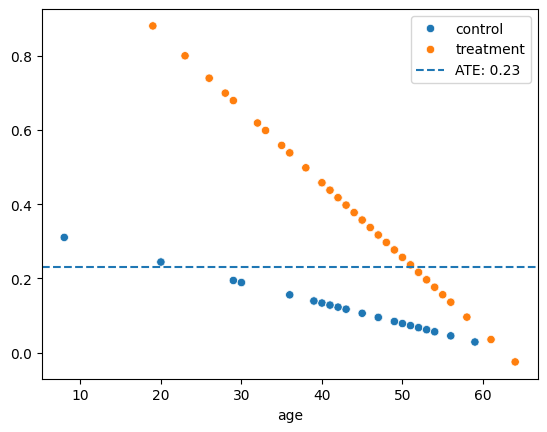

In [140]:
sns.scatterplot(df_heart, x="age", y=model3.predict(X3), hue="transplant")
plt.axhline(y=ate, linestyle="--", label=f"ATE: {ate:.2f}")
plt.legend()

In [144]:
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

mse1 = cross_val_score(model1, X1, y1, cv=kfold, scoring="neg_mean_squared_error") * -1
mse2 = cross_val_score(model2, X2, y2, cv=kfold, scoring="neg_mean_squared_error") * -1
mse3 = cross_val_score(model3, X3, y3, cv=kfold, scoring="neg_mean_squared_error") * -1

print(f"Model1: Mean Squared Error = {np.mean(mse1)}")
print(f"Model2: Mean Squared Error = {np.mean(mse2)}")
print(f"Model3: Mean Squared Error = {np.mean(mse3)}")

Model1: Mean Squared Error = 0.1936638397901797
Model2: Mean Squared Error = 0.18171967184387974
Model3: Mean Squared Error = 0.18067090272965328
